In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, json
from collections import Counter
warnings.filterwarnings('ignore')

import nltk
for r in ['punkt','punkt_tab','stopwords']:
    try: nltk.data.find(f'tokenizers/{r}' if 'punkt' in r else f'corpora/{r}')
    except: nltk.download(r, quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from wordcloud import WordCloud
print('Library berhasil di-import!')

Library berhasil di-import!


# **1. DATA PREPARATION**

In [2]:
# Membaca data yang sudah dilabeli dari Labeling_Data.ipynb
data = pd.read_csv('../dataset/data_pesan_telekomunikasi_opus4.6.csv')

# Hapus severity 0 (Non-Keluhan)
data = data[data['severity'] > 0].reset_index(drop=True)
data.rename(columns={'text': 'message'}, inplace=True)

print(f'Total data keluhan: {len(data):,}')
print(f'\nDistribusi severity (SETELAH hapus non-keluhan):')
for sev in sorted(data['severity'].unique()):
    count = (data['severity'] == sev).sum()
    pct = count / len(data) * 100
    print(f'  Severity {sev}: {count:>5,} ({pct:.1f}%)')


Total data keluhan: 18,216

Distribusi severity (SETELAH hapus non-keluhan):
  Severity 1: 3,339 (18.3%)
  Severity 2: 11,865 (65.1%)
  Severity 3: 2,067 (11.3%)
  Severity 4:   945 (5.2%)


In [3]:
from sklearn.utils import resample

severity_names = {1:'No Explicit Reproach', 2:'Disapproval', 3:'Accusation', 4:'Blame'}

# Kelas terkecil = Blame (944). Target = 944 + 10% = ~1038
min_count = data['severity'].value_counts().min()
TARGET = int(min_count * 1.1)
print(f'Kelas terkecil: {min_count}')
print(f'Target sampling: {TARGET} (min + 10%)')

balanced_parts = []
for sev in sorted(data['severity'].unique()):
    subset = data[data['severity'] == sev]
    if len(subset) > TARGET:
        subset = resample(subset, n_samples=TARGET, random_state=42, replace=False)
    balanced_parts.append(subset)

data = pd.concat(balanced_parts, ignore_index=True)
print(f'\nDistribusi setelah balancing:')
for sev in sorted(data['severity'].unique()):
    count = (data['severity'] == sev).sum()
    print(f'  Severity {sev} ({severity_names[sev]}): {count}')
print(f'Total: {len(data):,}')


Kelas terkecil: 945
Target sampling: 1039 (min + 10%)

Distribusi setelah balancing:
  Severity 1 (No Explicit Reproach): 1039
  Severity 2 (Disapproval): 1039
  Severity 3 (Accusation): 1039
  Severity 4 (Blame): 945
Total: 4,062


# **2. DATA CLEANING**

In [4]:
# Mengecek jumlah nilai yang kosong (NULL/NaN) di tiap kolom
print("Pengecekan missing values:")
print(data.isna().sum())

# Menghapus baris null dan duplikat
total = data.shape[0]
data.dropna(subset=['message'], inplace=True)
a = data.shape[0]
data.drop_duplicates(subset=['message'], inplace=True)
b = data.shape[0]
print(f'\nBaris null dihapus: {total - a}')
print(f'Baris duplikat dihapus: {a - b}')
print(f'Data tersisa: {b} baris')

Pengecekan missing values:
message     0
source      0
severity    0
dtype: int64

Baris null dihapus: 0
Baris duplikat dihapus: 281
Data tersisa: 3781 baris


# **3. TEXT PREPROCESSING**

In [5]:
## 1. CLEANING TEXT ##
# Fungsi untuk menghapus karakter yang tidak relevan
# DIPERBAIKI: lebih komprehensif menangani emoji, URL, mention,
# hashtag, karakter berulang, dan pola khusus media sosial
def clean_text(df, text_field, new_field):
    df[new_field] = df[text_field].apply(lambda x: str(x))
    # Hapus URL
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'https?://\S+|www\.\S+', ' ', x))
    # Hapus @mention dan #hashtag
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'(@|#)[A-Za-z0-9_]+', ' ', x))
    # Hapus emoji dan karakter Unicode non-ASCII
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'[^\x00-\x7F]+', ' ', x))
    # Hapus tanda baca dan karakter khusus
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'[^A-Za-z \t]', ' ', x))
    # Hapus karakter berulang >2x (misal: 'baguuuus' -> 'bagus')
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'(.)\1{2,}', r'\1', x))
    # Hapus spasi berlebih
    df[new_field] = df[new_field].apply(
        lambda x: re.sub(r'\s+', ' ', x).strip())
    # Hapus teks terlalu pendek (< 2 karakter)
    df[new_field] = df[new_field].apply(
        lambda x: x if len(x.strip()) >= 2 else '')
    return df

data = clean_text(data, 'message', 'cleaning_text')
data[['message', 'cleaning_text']].head()

,message,cleaning_text
0,"paket internet sakti tiba2 hilang, paket lain ...",paket internet sakti tiba hilang paket lain ma...
1,Terima kasih atas pesan Anda. *_RAYYA ~MARK~_...,Terima kasih atas pesan Anda RAYYA MARK sedang...
2,"Malam, tagihan untuk KM2111 berapa?",Malam tagihan untuk KM berapa
3,Ini sudah kami. Bayar dan kami ta tanyakan ke...,Ini sudah kami Bayar dan kami ta tanyakan kena...
4,Apa boleh dipasangkan🙏,Apa boleh dipasangkan


***CASE FOLDING***: Pengkonversian huruf menggunakan format huruf kecil seragam

In [6]:
## 2. CASE FOLDING ##
data['case_folding'] = data['cleaning_text'].str.lower()
data[['cleaning_text', 'case_folding']].head()

,cleaning_text,case_folding
0,paket internet sakti tiba hilang paket lain ma...,paket internet sakti tiba hilang paket lain ma...
1,Terima kasih atas pesan Anda RAYYA MARK sedang...,terima kasih atas pesan anda rayya mark sedang...
2,Malam tagihan untuk KM berapa,malam tagihan untuk km berapa
3,Ini sudah kami Bayar dan kami ta tanyakan kena...,ini sudah kami bayar dan kami ta tanyakan kena...
4,Apa boleh dipasangkan,apa boleh dipasangkan


***TOKENIZING***: Pemecahan kalimat menjadi potongan kata tunggal atau token

In [7]:
## 3. TOKENIZING ##
# Memisahkan kalimat menjadi potongan kata-kata tunggal (tokens) menggunakan NLTK
data['tokenizing'] = data['case_folding'].apply(lambda x: word_tokenize(x))
data[['case_folding', 'tokenizing']].head()

,case_folding,tokenizing
0,paket internet sakti tiba hilang paket lain ma...,"[paket, internet, sakti, tiba, hilang, paket, ..."
1,terima kasih atas pesan anda rayya mark sedang...,"[terima, kasih, atas, pesan, anda, rayya, mark..."
2,malam tagihan untuk km berapa,"[malam, tagihan, untuk, km, berapa]"
3,ini sudah kami bayar dan kami ta tanyakan kena...,"[ini, sudah, kami, bayar, dan, kami, ta, tanya..."
4,apa boleh dipasangkan,"[apa, boleh, dipasangkan]"


***NORMALISASI***: Perbaikan penulisan kata slang menjadi standard EYD (Ejaan)

In [8]:
## 4. NORMALISASI (Slang Words / Non-Standard) ##
def load_norm_dict(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
            if content.strip().startswith('{'): return json.loads(content)
            normd = {}
            for line in content.strip().split('\n'):
                parts = line.split('\t')
                if len(parts)==2: normd[parts[0].strip()] = parts[1].strip()
            return normd
    except Exception as e:
        print(f'Warning: {e}'); return {}

normd = load_norm_dict('../dataset/combined_slang_words.txt')
print(f'Kamus normalisasi: {len(normd)} kata')

def norm_term(document):
    return [normd.get(term, term) for term in document]

data['normalization'] = data['tokenizing'].apply(norm_term)
data[['tokenizing', 'normalization']].head()

Kamus normalisasi: 1090 kata


,tokenizing,normalization
0,"[paket, internet, sakti, tiba, hilang, paket, ...","[paket, internet, sakti, tiba, hilang, paket, ..."
1,"[terima, kasih, atas, pesan, anda, rayya, mark...","[terima, kasih, atas, pesan, anda, rayya, mark..."
2,"[malam, tagihan, untuk, km, berapa]","[malam, tagihan, untuk, kamu, berapa]"
3,"[ini, sudah, kami, bayar, dan, kami, ta, tanya...","[ini, sudah, kami, bayar, dan, kami, ta, tanya..."
4,"[apa, boleh, dipasangkan]","[apa, boleh, dipasangkan]"


***STOPWORDS REMOVAL***: Penghapusan kata tidak penting maupun kata penghubung

In [9]:
## 5. STOPWORDS REMOVAL (SASTRAWI LIBRARY) ##
# Menggunakan stopword bawaan Sastrawi (bukan file eksternal)
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

sw_factory = StopWordRemoverFactory()
sastrawi_stopwords = set(sw_factory.get_stop_words())

# Pertahankan kata negasi (penting untuk severity classification)
negasi = {'tidak','belum','bukan','jangan','tanpa','tak','tiada','enggan'}
sastrawi_stopwords -= negasi

print(f'Stopwords Sastrawi: {len(sastrawi_stopwords)} kata (negasi dipertahankan)')

def remove_stopwords_sastrawi(tokens):
    return [w for w in tokens if w not in sastrawi_stopwords]

data['remove_stopwords'] = data['normalization'].apply(remove_stopwords_sastrawi)
data[['normalization', 'remove_stopwords']].head()


Stopwords Sastrawi: 803 kata (negasi dipertahankan)


,normalization,remove_stopwords
0,"[paket, internet, sakti, tiba, hilang, paket, ...","[paket, internet, sakti, hilang, paket, mengur..."
1,"[terima, kasih, atas, pesan, anda, rayya, mark...","[terima, kasih, pesan, rayya, mark, tidak, mer..."
2,"[malam, tagihan, untuk, kamu, berapa]","[malam, tagihan]"
3,"[ini, sudah, kami, bayar, dan, kami, ta, tanya...","[bayar, ta, nama, bambang, endang, rahayu]"
4,"[apa, boleh, dipasangkan]",[dipasangkan]


***STEMMING***: Penguraian kalimat sesuai bentuk makna dasarnya dengan menghapus imbuhan kata

In [10]:
## 6. STEMMING (SASTRAWI) ## 
# Sastrawi adalah library stemming terbaik untuk Bahasa Indonesia
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Optimasi: Daftarkan semua kata unik untuk mempercepat proses (Caching)
termd = {}
for doc in data['remove_stopwords']:
    for term in doc:
        if term not in termd: termd[term] = ' '

print(f'Stemming {len(termd)} kata unik (harap tunggu)...')
for term in termd:
    termd[term] = stemmer.stem(term)
print('Stemming dictionary selesai!')

def get_stemmed_term(document):
    return [termd[t] for t in document if t in termd]

data['stemming'] = data['remove_stopwords'].apply(get_stemmed_term)
data[['remove_stopwords', 'stemming']].head()

Stemming 5645 kata unik (harap tunggu)...


Stemming dictionary selesai!


,remove_stopwords,stemming
0,"[paket, internet, sakti, hilang, paket, mengur...","[paket, internet, sakti, hilang, paket, uras, ..."
1,"[terima, kasih, pesan, rayya, mark, tidak, mer...","[terima, kasih, pesan, rayya, mark, tidak, res..."
2,"[malam, tagihan]","[malam, tagih]"
3,"[bayar, ta, nama, bambang, endang, rahayu]","[bayar, ta, nama, bambang, endang, rahayu]"
4,[dipasangkan],[pasang]


In [11]:
# Gabungkan kembali list kata (Array of strings) ke Teks tunggal (string)
# Sklearn TfidfVectorizer membutuhkan format kalimat, bukan Array kata
data['clean_text'] = data['stemming'].apply(lambda x: ' '.join(x))
data = data[data['clean_text'].str.strip() != ''].copy()
print(f'Data siap: {len(data)} baris')

# Lihat perubahan Teks Mentah vs Teks Bersih
data[['message', 'clean_text']].head()

Data siap: 3781 baris


,message,clean_text
0,"paket internet sakti tiba2 hilang, paket lain ...",paket internet sakti hilang paket uras dompet ...
1,Terima kasih atas pesan Anda. *_RAYYA ~MARK~_...,terima kasih pesan rayya mark tidak respons cepat
2,"Malam, tagihan untuk KM2111 berapa?",malam tagih
3,Ini sudah kami. Bayar dan kami ta tanyakan ke...,bayar ta nama bambang endang rahayu
4,Apa boleh dipasangkan🙏,pasang


# **EKSPLORASI DATA & WORDCLOUD**

Distribusi severity:
severity
1     990
2    1027
3     959
4     805
Name: count, dtype: int64


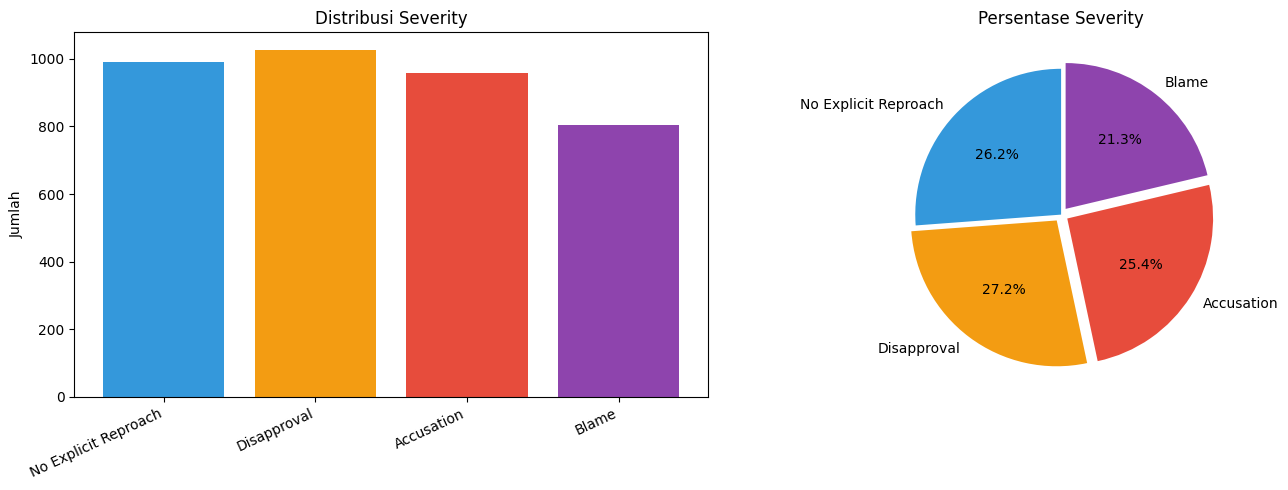

In [12]:
# Distribusi severity setelah preprocessing
severity_names = {1:'No Explicit Reproach', 2:'Disapproval', 3:'Accusation', 4:'Blame'}
colors = ['#3498db','#f39c12','#e74c3c','#8e44ad']

severity_counts = data['severity'].value_counts().sort_index()
print('Distribusi severity:')
print(severity_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar([severity_names[i] for i in severity_counts.index], severity_counts.values, color=colors)
axes[0].set_title('Distribusi Severity'); axes[0].set_ylabel('Jumlah')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha='right')

explode = [0.05 if x != 1 else 0 for x in severity_counts.index]
axes[1].pie(severity_counts.values, labels=[severity_names[i] for i in severity_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90, explode=explode)
axes[1].set_title('Persentase Severity')
plt.tight_layout(); plt.show()

Statistik jumlah kata (setelah preprocessing) per severity:
          jumlah  rata2_kata  min_kata  max_kata
severity                                        
1            990         8.4         1        45
2           1027         9.2         1       117
3            959        12.8         1        56
4            805        17.4         1        64


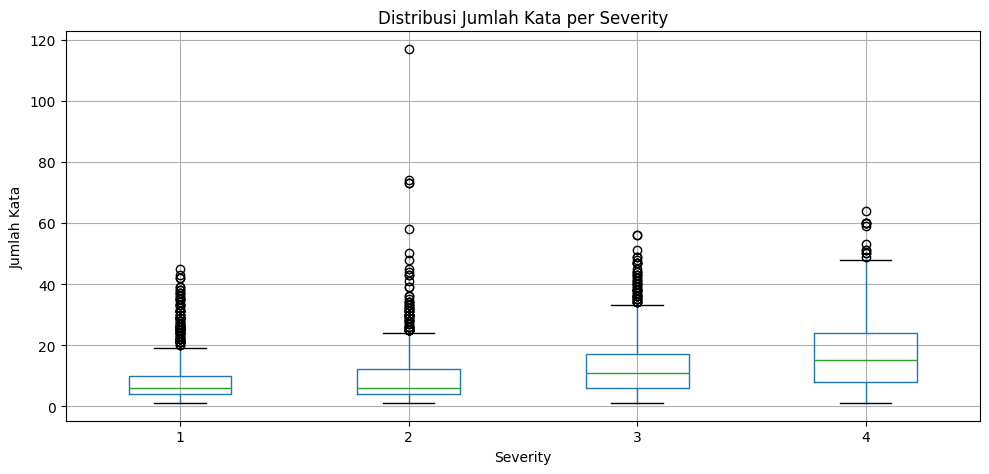

In [13]:
# Statistik panjang teks bersih per severity
data['clean_len'] = data['clean_text'].apply(lambda x: len(x.split()))

stats = data.groupby('severity').agg(
    jumlah=('clean_text','count'),
    rata2_kata=('clean_len','mean'),
    min_kata=('clean_len','min'),
    max_kata=('clean_len','max')
).round(1)
print('Statistik jumlah kata (setelah preprocessing) per severity:')
print(stats)

fig, ax = plt.subplots(figsize=(10, 5))
data.boxplot(column='clean_len', by='severity', ax=ax)
ax.set_title('Distribusi Jumlah Kata per Severity'); ax.set_xlabel('Severity'); ax.set_ylabel('Jumlah Kata')
plt.suptitle(''); plt.tight_layout(); plt.show()

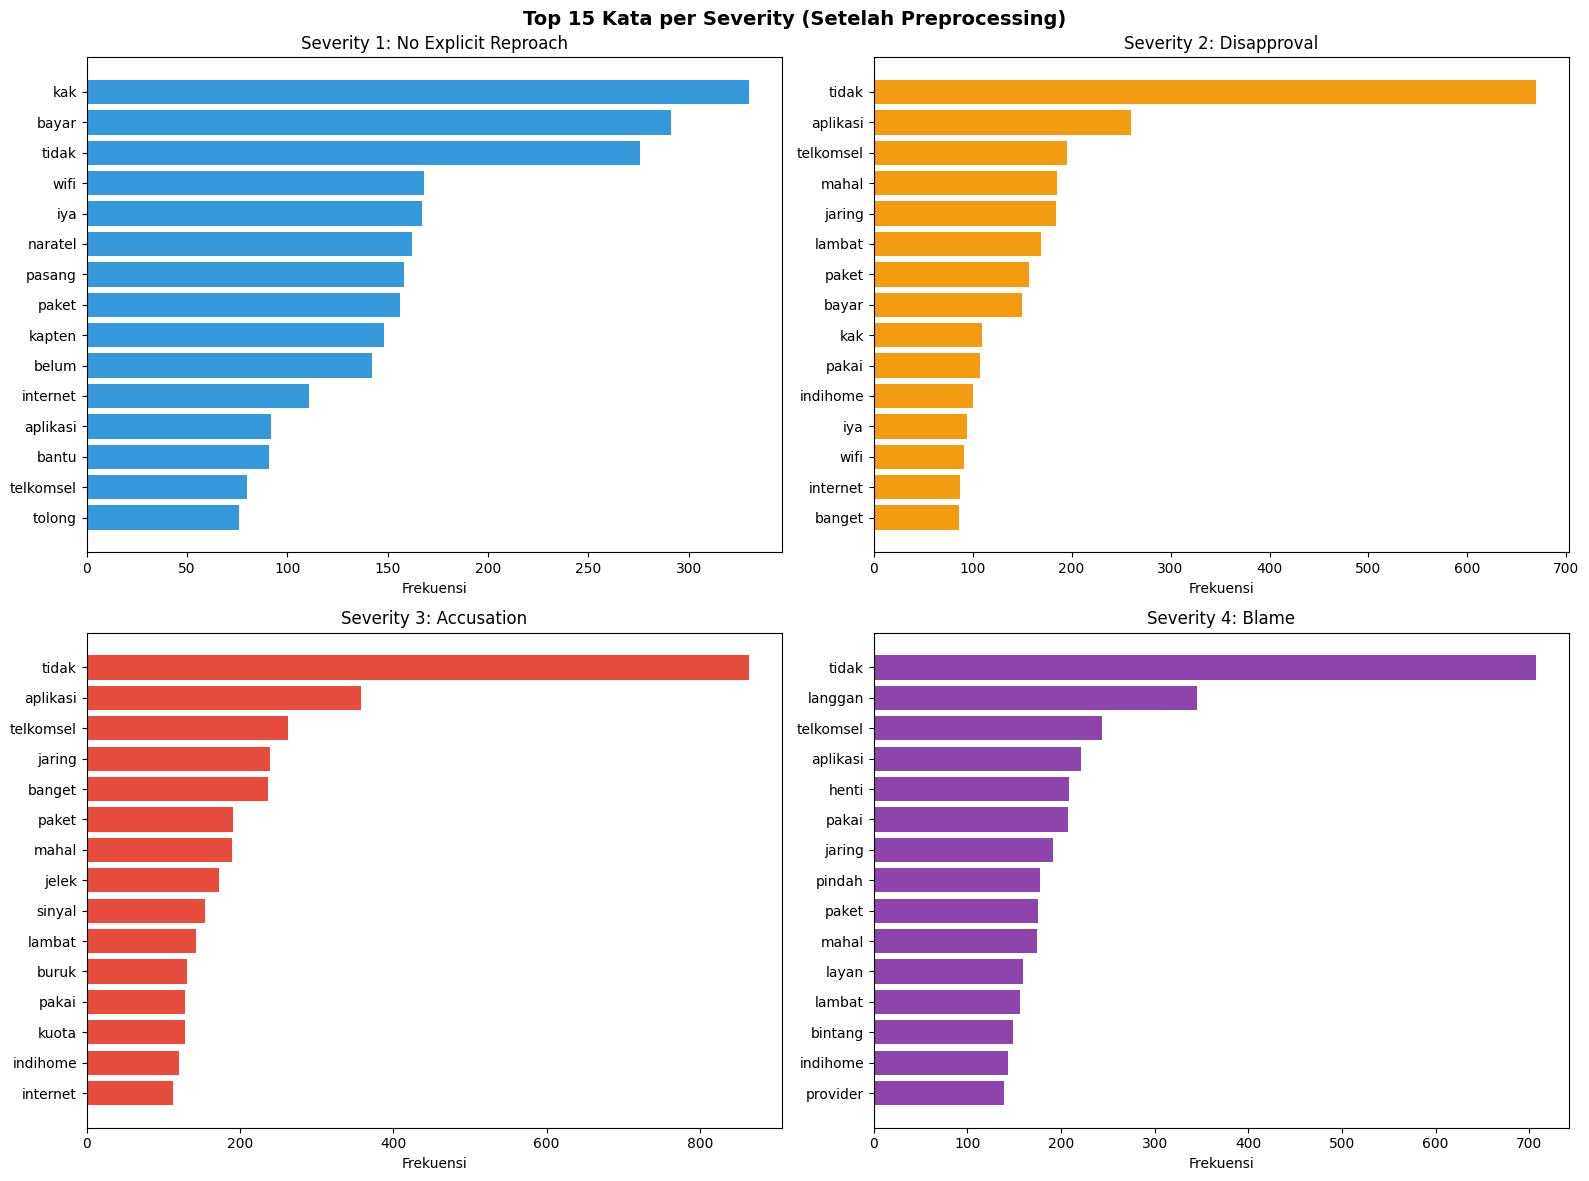

In [14]:
# Top 15 kata paling sering per severity (setelah preprocessing)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, sev in enumerate(sorted(data['severity'].unique())):
    ax = axes[idx//2][idx%2]
    words = ' '.join(data[data['severity']==sev]['clean_text']).split()
    words = [w for w in words if len(w) > 2]
    top15 = Counter(words).most_common(15)
    if top15:
        w, cnt = zip(*top15)
        ax.barh(range(len(w)), cnt, color=colors[sev-1])
        ax.set_yticks(range(len(w))); ax.set_yticklabels(w)
        ax.invert_yaxis()
    ax.set_title(f'Severity {sev}: {severity_names.get(sev,sev)}')
    ax.set_xlabel('Frekuensi')
plt.suptitle('Top 15 Kata per Severity (Setelah Preprocessing)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

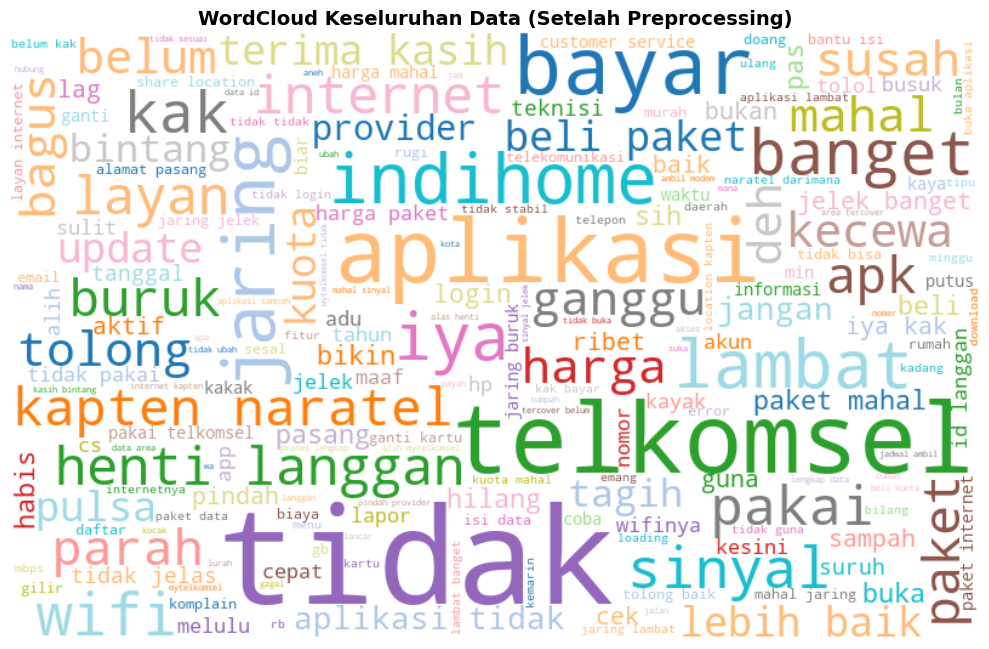

In [15]:
# Wordcloud untuk keseluruhan data yang telah diproses
all_words = ' '.join(data['clean_text'])
word_cloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110,
                       background_color='white', colormap='tab20').generate(all_words)
plt.figure(figsize=(10, 7))
plt.imshow(word_cloud, interpolation="bilinear")
plt.title('WordCloud Keseluruhan Data (Setelah Preprocessing)', fontsize=14, fontweight='bold')
plt.axis('off'); plt.tight_layout(); plt.show()

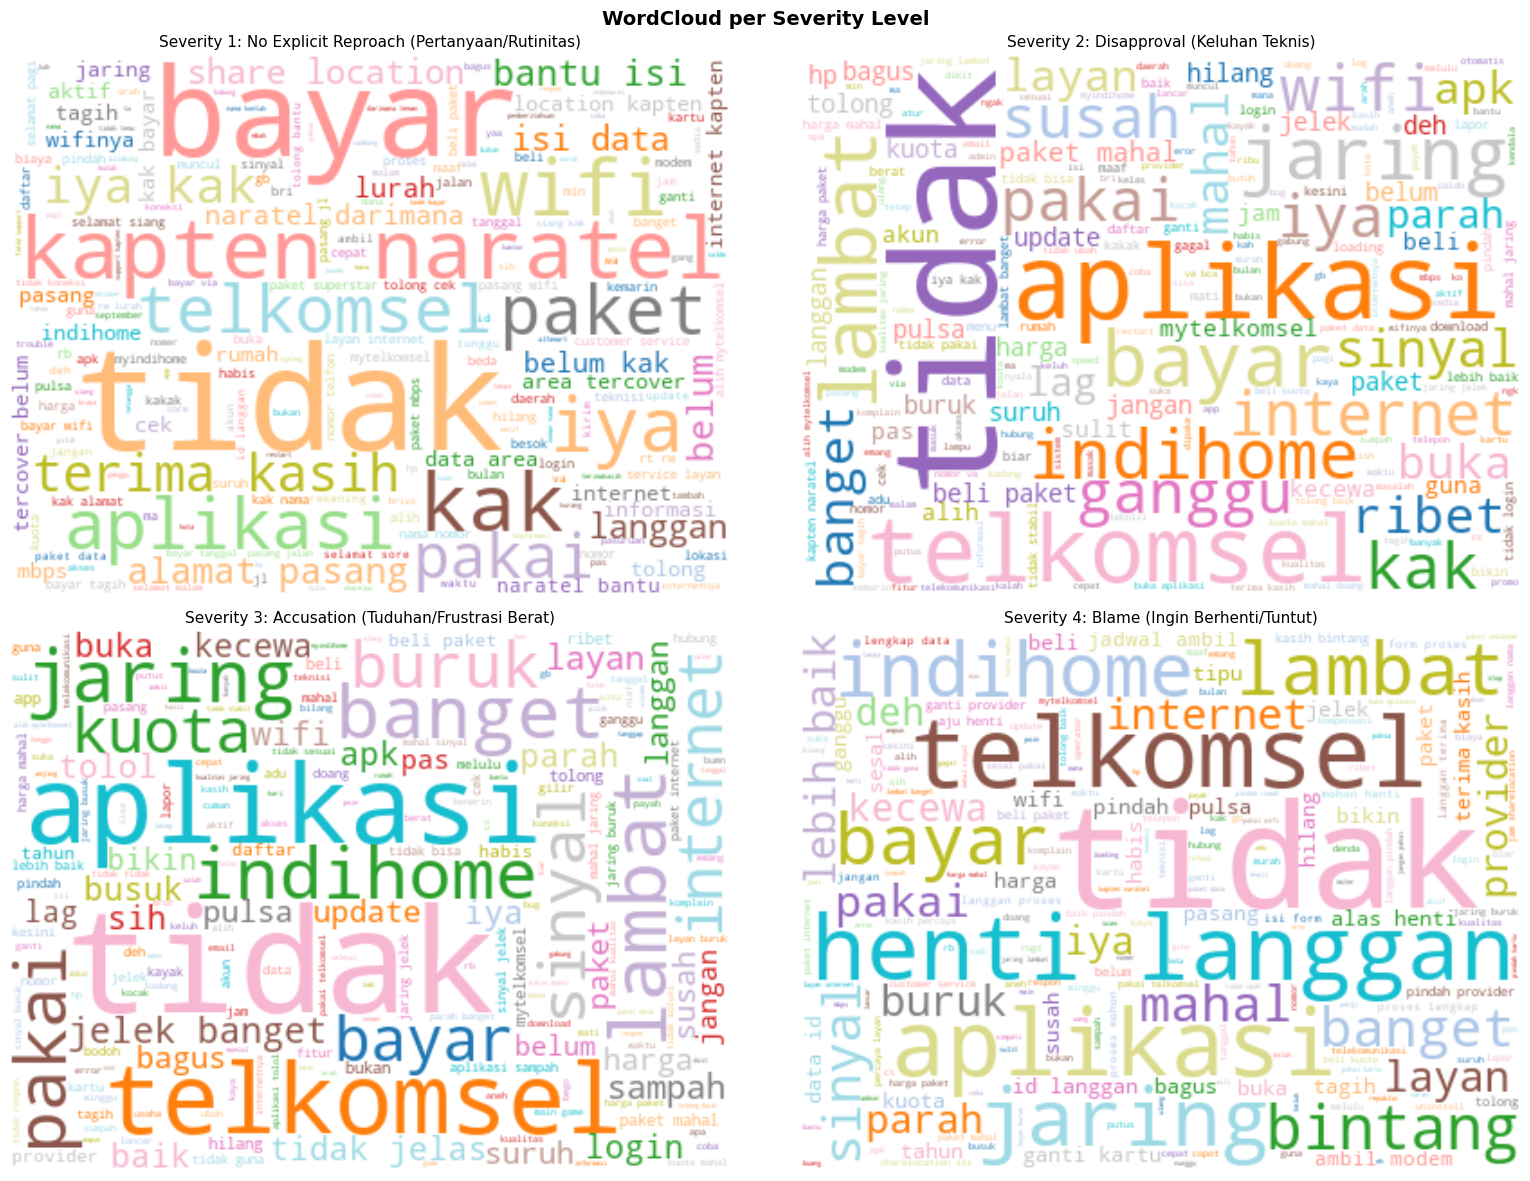

In [16]:
# Wordcloud per severity level
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
wc_titles = {4:'Severity 4: Blame (Ingin Berhenti/Tuntut)',
             3:'Severity 3: Accusation (Tuduhan/Frustrasi Berat)',
             2:'Severity 2: Disapproval (Keluhan Teknis)',
             1:'Severity 1: No Explicit Reproach (Pertanyaan/Rutinitas)'}
for idx, sev in enumerate([1,2,3,4]):
    ax = axes[idx//2][idx%2]
    words = ' '.join(data[data['severity']==sev]['clean_text'])
    if len(words.strip()) > 0:
        wc = WordCloud(width=400, height=300, background_color='white',
                      colormap='tab20', max_font_size=80).generate(words)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(wc_titles[sev], fontsize=11); ax.axis('off')
plt.suptitle('WordCloud per Severity Level', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# **5. FEATURE SELECTION / EXTRACTION**

In [17]:
# 1. Feature Extraction (TF-IDF) dengan Bigram
# Bigram menangkap frasa penting: "tidak bisa", "sangat buruk", dll
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X = tfidf.fit_transform(data['clean_text']).toarray()
y = data['severity'].values
print(f'TF-IDF shape: {X.shape} (unigram + bigram)')
print(f'Jumlah fitur: {len(tfidf.get_feature_names_out())}')

TF-IDF shape: (3781, 8000) (unigram + bigram)
Jumlah fitur: 8000


In [18]:
# 2. Train-Test Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'Train dist: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test dist:  {dict(zip(*np.unique(y_test, return_counts=True)))}')

Train: 3024, Test: 757
Train dist: {np.int64(1): np.int64(792), np.int64(2): np.int64(821), np.int64(3): np.int64(767), np.int64(4): np.int64(644)}
Test dist:  {np.int64(1): np.int64(198), np.int64(2): np.int64(206), np.int64(3): np.int64(192), np.int64(4): np.int64(161)}


## **EVALUASI**

=== Alpha Tuning (MultinomialNB) ===


  alpha=0.01  -> CV Accuracy: 0.6121


  alpha=0.05  -> CV Accuracy: 0.6319


  alpha=0.1   -> CV Accuracy: 0.6445


  alpha=0.2   -> CV Accuracy: 0.6501


...

  alpha=0.5   -> CV Accuracy: 0.6554


  alpha=0.7   -> CV Accuracy: 0.6564


  alpha=1.0   -> CV Accuracy: 0.6554


  alpha=1.5   -> CV Accuracy: 0.6591


  alpha=2.0   -> CV Accuracy: 0.6541

Best alpha: 1.5 (CV Accuracy: 0.6591)

===== Multinomial Naive Bayes (alpha=1.5) =====
Accuracy:  0.6764
Precision: 0.6978
Recall:    0.6774
F1-score:  0.6785

Classification Report:
                      precision    recall  f1-score   support

No Explicit Reproach       0.72      0.77      0.74       198
         Disapproval       0.65      0.51      0.57       206
          Accusation       0.58      0.78      0.67       192
               Blame       0.85      0.65      0.73       161

            accuracy                           0.68       757
           macro avg       0.70      0.68      0.68       757
        weighted avg       0.69      0.68      0.67       757



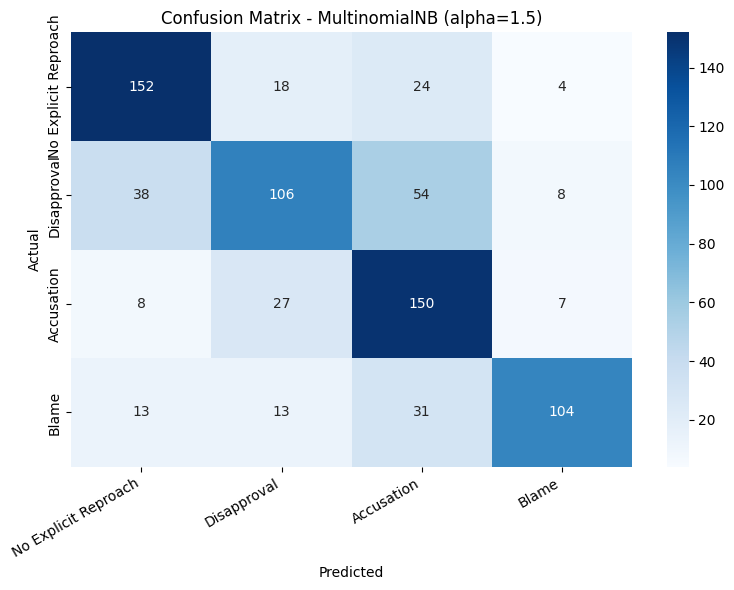


===== Complement Naive Bayes (alpha=1.5) =====
Accuracy:  0.6830
Precision: 0.6876
Recall:    0.6924
F1-score:  0.6757

Classification Report:
                      precision    recall  f1-score   support

No Explicit Reproach       0.69      0.79      0.74       198
         Disapproval       0.70      0.39      0.50       206
          Accusation       0.64      0.78      0.70       192
               Blame       0.71      0.81      0.76       161

            accuracy                           0.68       757
           macro avg       0.69      0.69      0.68       757
        weighted avg       0.69      0.68      0.67       757



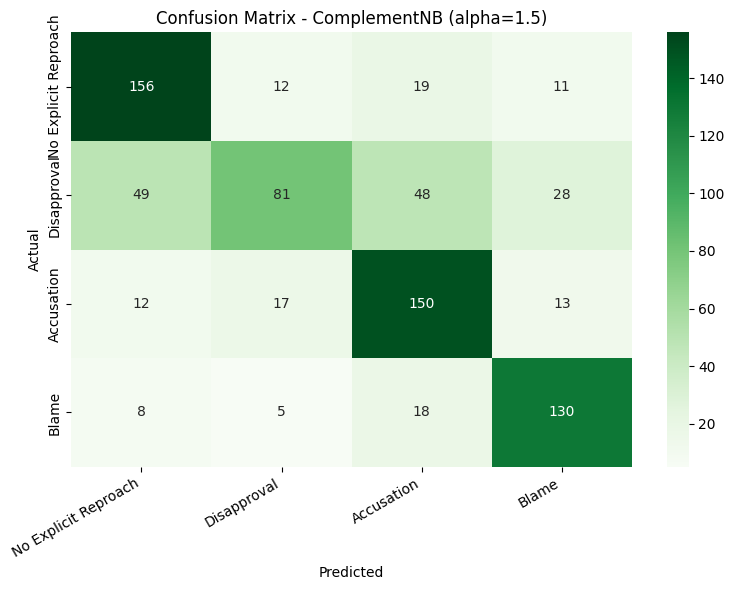

In [19]:
# 3a. Alpha Tuning — cari alpha terbaik untuk MultinomialNB
from sklearn.model_selection import cross_val_score

alphas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
best_alpha, best_cv = 0.5, 0
print('=== Alpha Tuning (MultinomialNB) ===')
for a in alphas:
    scores = cross_val_score(MultinomialNB(alpha=a), X_train, y_train, cv=5, scoring='accuracy')
    mean_s = scores.mean()
    print(f'  alpha={a:<5} -> CV Accuracy: {mean_s:.4f}')
    if mean_s > best_cv:
        best_cv = mean_s
        best_alpha = a
print(f'\nBest alpha: {best_alpha} (CV Accuracy: {best_cv:.4f})')

# 3b. MultinomialNB dengan alpha terbaik
clf_nb = MultinomialNB(alpha=best_alpha)
clf_nb.fit(X_train, y_train)
y_pred_nb = clf_nb.predict(X_test)

print(f'\n===== Multinomial Naive Bayes (alpha={best_alpha}) =====')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_nb, average="macro", zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_nb, average="macro", zero_division=0):.4f}')
print(f'F1-score:  {f1_score(y_test, y_pred_nb, average="macro", zero_division=0):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb,
      target_names=[severity_names[i] for i in sorted(np.unique(y))], zero_division=0))

cm_nb = confusion_matrix(y_test, y_pred_nb)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=[severity_names[i] for i in sorted(np.unique(y))],
            yticklabels=[severity_names[i] for i in sorted(np.unique(y))], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - MultinomialNB (alpha={best_alpha})')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

# 3c. ComplementNB (dirancang untuk data imbalanced, sering lebih baik dari MultinomialNB)
from sklearn.naive_bayes import ComplementNB

clf_cnb = ComplementNB(alpha=best_alpha)
clf_cnb.fit(X_train, y_train)
y_pred_cnb = clf_cnb.predict(X_test)

print(f'\n===== Complement Naive Bayes (alpha={best_alpha}) =====')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_cnb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_cnb, average="macro", zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_cnb, average="macro", zero_division=0):.4f}')
print(f'F1-score:  {f1_score(y_test, y_pred_cnb, average="macro", zero_division=0):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_cnb,
      target_names=[severity_names[i] for i in sorted(np.unique(y))], zero_division=0))

cm_cnb = confusion_matrix(y_test, y_pred_cnb)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_cnb, annot=True, fmt='d', cmap='Greens',
            xticklabels=[severity_names[i] for i in sorted(np.unique(y))],
            yticklabels=[severity_names[i] for i in sorted(np.unique(y))], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - ComplementNB (alpha={best_alpha})')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


## **KOMPARASI: Support Vector Machine (SVM)**

===== Support Vector Machine (SVM Linear) =====
Accuracy:  0.7649
Precision: 0.7705
Recall:    0.7682
F1-score:  0.7686

Classification Report:
                      precision    recall  f1-score   support

No Explicit Reproach       0.76      0.84      0.80       198
         Disapproval       0.71      0.70      0.70       206
          Accusation       0.75      0.70      0.73       192
               Blame       0.86      0.83      0.85       161

            accuracy                           0.76       757
           macro avg       0.77      0.77      0.77       757
        weighted avg       0.77      0.76      0.76       757



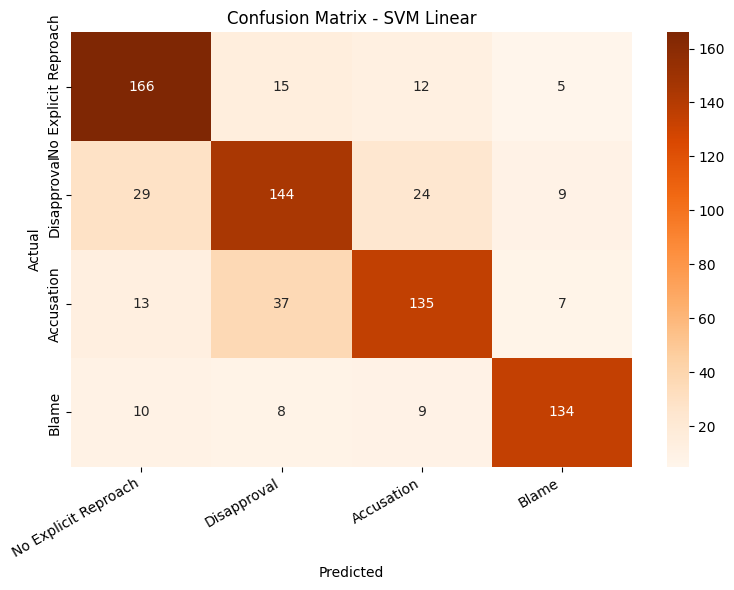


===== Support Vector Machine (SVM Polynomial, degree=3) =====
Accuracy:  0.5627
Precision: 0.7022
Recall:    0.5445
F1-score:  0.5476

Classification Report:
                      precision    recall  f1-score   support

No Explicit Reproach       0.81      0.58      0.67       198
         Disapproval       0.41      0.85      0.55       206
          Accusation       0.68      0.51      0.58       192
               Blame       0.91      0.24      0.38       161

            accuracy                           0.56       757
           macro avg       0.70      0.54      0.55       757
        weighted avg       0.69      0.56      0.56       757



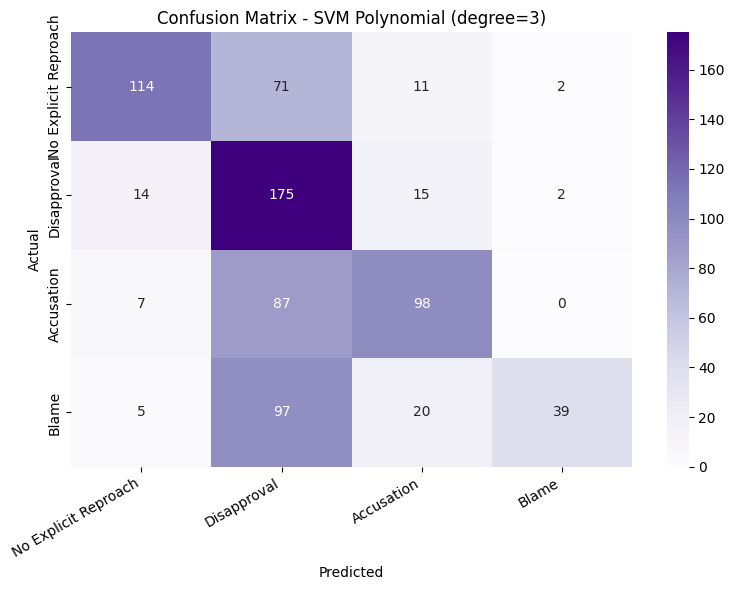

In [20]:
# 4. Model Training SVM (Linear Kernel)
clf_svm = SVC(kernel='linear', random_state=42)
clf_svm.fit(X_train, y_train)
y_pred_svm = clf_svm.predict(X_test)

print("===== Support Vector Machine (SVM Linear) =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm, average='macro', zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm, average='macro', zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm,
      target_names=[severity_names[i] for i in sorted(np.unique(y))], zero_division=0))

cm_svm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=[severity_names[i] for i in sorted(np.unique(y))],
            yticklabels=[severity_names[i] for i in sorted(np.unique(y))], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - SVM Linear')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

# 5. Model Training SVM (Polynomial Kernel)
clf_svm_poly = SVC(kernel='poly', degree=3, random_state=42)
clf_svm_poly.fit(X_train, y_train)
y_pred_svm_poly = clf_svm_poly.predict(X_test)

print("\n===== Support Vector Machine (SVM Polynomial, degree=3) =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm_poly):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_poly, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm_poly, average='macro', zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm_poly, average='macro', zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_poly,
      target_names=[severity_names[i] for i in sorted(np.unique(y))], zero_division=0))

cm_poly = confusion_matrix(y_test, y_pred_svm_poly)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Purples',
            xticklabels=[severity_names[i] for i in sorted(np.unique(y))],
            yticklabels=[severity_names[i] for i in sorted(np.unique(y))], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - SVM Polynomial (degree=3)')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


## **PERBANDINGAN NAIVE BAYES vs SVM**

=== PERBANDINGAN SEMUA MODEL ===


                Model  Accuracy  Precision   Recall  F1-Score
MultinomialNB (a=1.5)  0.676354   0.697850 0.677363  0.678458
 ComplementNB (a=1.5)  0.682959   0.687566 0.692447  0.675714
           SVM Linear  0.764861   0.770467 0.768209  0.768606
       SVM Poly (d=3)  0.562748   0.702199 0.544481  0.547639


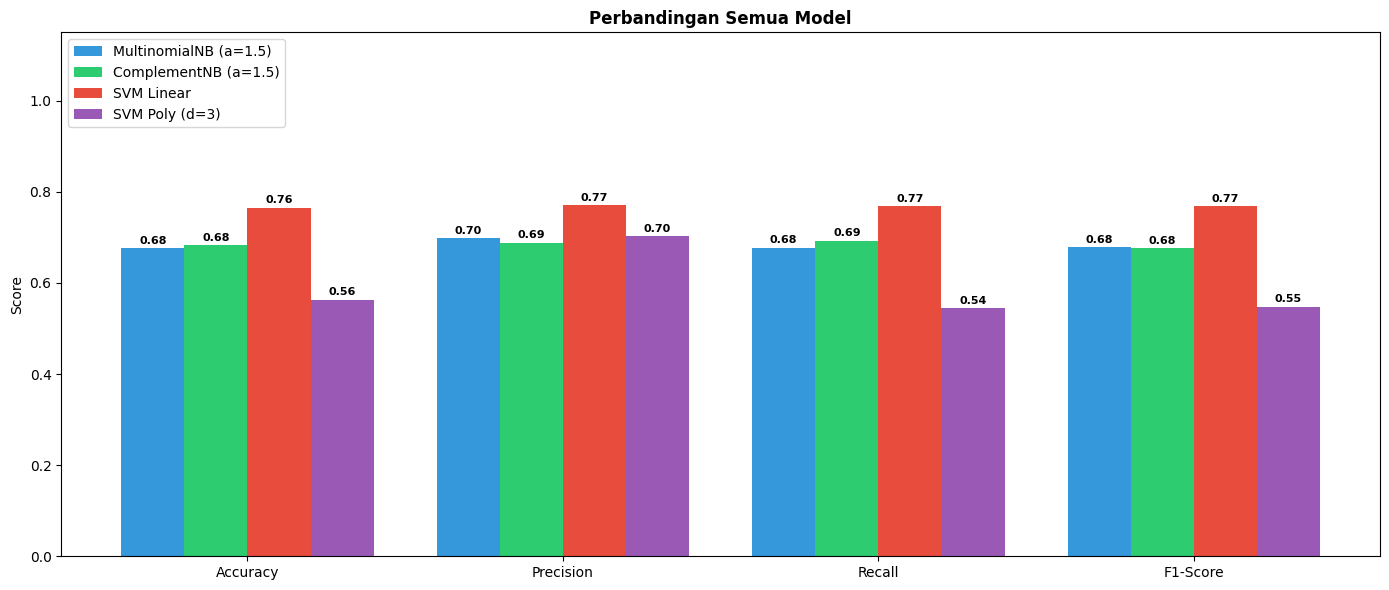

In [21]:
# Tabel Perbandingan Semua Model
results = {
    'Model': [f'MultinomialNB (a={best_alpha})', f'ComplementNB (a={best_alpha})', 'SVM Linear', 'SVM Poly (d=3)'],
    'Accuracy': [accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_cnb),
                 accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_svm_poly)],
    'Precision': [precision_score(y_test, y_pred_nb, average='macro', zero_division=0),
                  precision_score(y_test, y_pred_cnb, average='macro', zero_division=0),
                  precision_score(y_test, y_pred_svm, average='macro', zero_division=0),
                  precision_score(y_test, y_pred_svm_poly, average='macro', zero_division=0)],
    'Recall': [recall_score(y_test, y_pred_nb, average='macro', zero_division=0),
               recall_score(y_test, y_pred_cnb, average='macro', zero_division=0),
               recall_score(y_test, y_pred_svm, average='macro', zero_division=0),
               recall_score(y_test, y_pred_svm_poly, average='macro', zero_division=0)],
    'F1-Score': [f1_score(y_test, y_pred_nb, average='macro', zero_division=0),
                 f1_score(y_test, y_pred_cnb, average='macro', zero_division=0),
                 f1_score(y_test, y_pred_svm, average='macro', zero_division=0),
                 f1_score(y_test, y_pred_svm_poly, average='macro', zero_division=0)]
}
df_compare = pd.DataFrame(results)
print('=== PERBANDINGAN SEMUA MODEL ===')
print(df_compare.to_string(index=False))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
vals = [[results[m][i] for m in metrics] for i in range(4)]
labels = results['Model']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

x = np.arange(len(metrics))
width = 0.2
fig, ax = plt.subplots(figsize=(14, 6))
for i in range(4):
    bars = ax.bar(x + (i-1.5)*width, vals[i], width, label=labels[i], color=colors[i])
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.2f}', ha='center', fontweight='bold', fontsize=8)
ax.set_ylabel('Score'); ax.set_title('Perbandingan Semua Model', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.legend(loc='upper left'); ax.set_ylim(0, 1.15)
plt.tight_layout(); plt.show()


# **OUTPUT NLP**

In [22]:
# Terapkan prediksi ke seluruh dataset internal untuk dibawa ke model Decision Tree
import os

df_internal = data[data['source']=='internal'].copy() if 'source' in data.columns else data.copy()
X_int = tfidf.transform(df_internal['clean_text']).toarray()
df_internal['predicted_severity'] = clf_nb.predict(X_int)
print('Distribusi predicted severity:')
print(df_internal['predicted_severity'].value_counts().sort_index())

# Merge kode_user dan aggregasi per user
df_orig = pd.read_csv('../dataset/data_pesan_customer.csv')
df_result = df_internal[['message','clean_text','severity','predicted_severity']].merge(
    df_orig[['message','kode_user']], on='message', how='left')
df_result.dropna(subset=['kode_user'], inplace=True)

severity_per_user = df_result.groupby('kode_user')['predicted_severity'].max().reset_index()
print(f'\nUser unik: {len(severity_per_user)}')
print(f'Distribusi severity per user:')
print(severity_per_user['predicted_severity'].value_counts().sort_index())

# Simpan output
os.makedirs('../output', exist_ok=True)
df_result.to_csv('../output/data_with_severity.csv', index=False)
severity_per_user.to_csv('../output/severity_per_user.csv', index=False)
data.to_csv('../output/data_preprocessed.csv', index=False)

print('\nOutput tersimpan:')
print('  - output/data_with_severity.csv')
print('  - output/severity_per_user.csv -> input Pipeline Churn (Decision Tree)')
print('  - output/data_preprocessed.csv')

Distribusi predicted severity:
predicted_severity
1    897
2    272
3     23
4    131
Name: count, dtype: int64

User unik: 682
Distribusi severity per user:
predicted_severity
1    392
2    183
3     17
4     90
Name: count, dtype: int64

Output tersimpan:
  - output/data_with_severity.csv
  - output/severity_per_user.csv -> input Pipeline Churn (Decision Tree)
  - output/data_preprocessed.csv
